# 🏦 Prêt à Dépenser — Scoring Crédit
## Étape 3 : Comparaison des modèles de classification

**Objectif :** Entraîner et comparer plusieurs familles de modèles avec validation croisée StratifiedKFold, métriques adaptées et score métier personnalisé.

| Modèle | Famille | Gestion déséquilibre |
|--------|---------|---------------------|
| Régression Logistique | Linéaire | class_weight=balanced |
| Random Forest | Bagging | class_weight=balanced |
| LightGBM | Boosting | class_weight=balanced |
| XGBoost | Boosting | scale_pos_weight |
| MLP | Réseau de neurones | class_weight=balanced |

> **Prérequis :** `output/train_prepared.csv` et `output/test_prepared.csv` issus de l'étape 1


---
## ⚙️ 0. Configuration & Imports

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.xgboost

# Modèles
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Évaluation
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    recall_score, confusion_matrix, roc_curve
)

warnings.filterwarnings("ignore")

# ── Chemins ───────────────────────────────────────────────────────
OUTPUT_DIR  = "../output"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
COLORS = ["#1D9E75", "#378ADD", "#D85A30", "#BA7517", "#7B4FBF"]

print("✅ Configuration OK")


✅ Configuration OK


---
## 📂 1. Chargement & Préparation

In [2]:
train = pd.read_csv(os.path.join(OUTPUT_DIR, "train_prepared.csv"))
test  = pd.read_csv(os.path.join(OUTPUT_DIR, "test_prepared.csv"))

# Suppression redondances
COLS_DROP = ["DAYS_BIRTH", "DAYS_EMPLOYED", "INS_IS_LATE_MEAN"]
train = train.drop(columns=[c for c in COLS_DROP if c in train.columns])
test  = test.drop(columns=[c for c in COLS_DROP if c in test.columns])

# Nettoyage noms colonnes (LightGBM/XGBoost)
def clean_cols(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', c) for c in df.columns]
    return df

train = clean_cols(train)
test  = clean_cols(test)

X_full = train.drop(columns=["SK_ID_CURR", "TARGET"])
y      = train["TARGET"]
X_test = test.drop(columns=["SK_ID_CURR"], errors="ignore")

# Top 200 features (corrélation avec TARGET)
correlations      = X_full.corrwith(y).abs().sort_values(ascending=False)
TOP_200           = correlations.head(200).index.tolist()
X                 = X_full[TOP_200]
X_test            = X_test[[c for c in TOP_200 if c in X_test.columns]]

scale_pw = (y == 0).sum() / (y == 1).sum()

print(f"Train  : {X.shape[0]:,} lignes × {X.shape[1]} features")
print(f"Test   : {X_test.shape[0]:,} lignes × {X_test.shape[1]} features")
print(f"Défauts: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"scale_pos_weight: {scale_pw:.2f}")


Train  : 307,511 lignes × 200 features
Test   : 48,744 lignes × 200 features
Défauts: 24,825 (8.1%)
scale_pos_weight: 11.39


---
## 🧮 2. Fonctions utilitaires

In [3]:
# ── MLflow ────────────────────────────────────────────────────────
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
EXPERIMENT_NAME = "scoring_credit_comparaison_modeles"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"✅ MLflow configuré : {EXPERIMENT_NAME}")

# ── CV ────────────────────────────────────────────────────────────
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Score métier ──────────────────────────────────────────────────
def cout_metier(y_true, y_proba, seuil, fn=10, fp=1):
    y_pred = (y_proba >= seuil).astype(int)
    tn, fpp, fnn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fnn + fp * fpp

def seuil_optimal(y_true, y_proba, n=200):
    seuils = np.linspace(0.01, 0.99, n)
    couts  = [cout_metier(y_true, y_proba, s) for s in seuils]
    idx    = np.argmin(couts)
    return seuils[idx], couts[idx], seuils, couts

def evaluer(y_true, y_proba):
    seuil_opt, cout_min, _, _ = seuil_optimal(y_true, y_proba)
    y_pred = (y_proba >= seuil_opt).astype(int)
    return {
        "auc"        : roc_auc_score(y_true, y_proba),
        "accuracy"   : accuracy_score(y_true, y_pred),
        "f1"         : f1_score(y_true, y_pred),
        "recall_1"   : recall_score(y_true, y_pred),
        "cout"       : cout_min,
        "seuil_opt"  : seuil_opt,
    }

print("✅ Fonctions définies")


2026/08/01 00:29:03 INFO mlflow.tracking.fluent: Experiment with name 'scoring_credit_comparaison_modeles' does not exist. Creating a new experiment.


✅ MLflow configuré : scoring_credit_comparaison_modeles
✅ Fonctions définies


---
## 🔄 3. Entraînement & Comparaison des modèles

On entraîne 5 modèles avec **StratifiedKFold 5 folds** et on logue chaque run dans MLflow.


In [4]:
# ── Définition des modèles ────────────────────────────────────────
MODELES = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.01, max_iter=500, class_weight="balanced",
            solver="saga", n_jobs=1, random_state=42
        ))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight="balanced", n_jobs=1,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500, learning_rate=0.02,
        num_leaves=63, min_child_samples=20,
        class_weight="balanced",
        n_jobs=1, verbose=-1, random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, scale_pos_weight=scale_pw,
        n_jobs=1, verbosity=0,
        eval_metric="auc", random_state=42
    ),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            max_iter=100, early_stopping=True,
            random_state=42
        ))
    ]),
}

# Top 100 features pour LogReg et MLP (plus rapide)
TOP_100 = correlations.head(100).index.tolist()
X_lr    = X_full[TOP_100]

print("Modèles configurés :")
for nom in MODELES:
    print(f"  ✓ {nom}")


Modèles configurés :
  ✓ LogisticRegression
  ✓ RandomForest
  ✓ LightGBM
  ✓ XGBoost
  ✓ MLP


In [5]:
from IPython.display import display

# ── Boucle d'entraînement ─────────────────────────────────────────
resultats = {}

for nom, modele in MODELES.items():
    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")

    # LogReg et MLP → 100 features, autres → 200
    X_mod = X_lr if nom in ["LogisticRegression", "MLP"] else X

    with mlflow.start_run(run_name=nom) as run:

        mlflow.set_tags({
            "modele"  : nom,
            "dataset" : "home_credit",
            "n_features": X_mod.shape[1],
        })
        mlflow.log_param("n_features", X_mod.shape[1])
        mlflow.log_param("n_folds",    5)

        aucs, f1s, recalls, couts, seuils = [], [], [], [], []

        for fold, (idx_tr, idx_val) in enumerate(SKF.split(X_mod, y), 1):
            X_tr  = X_mod.iloc[idx_tr]
            X_val = X_mod.iloc[idx_val]
            y_tr  = y.iloc[idx_tr]
            y_val = y.iloc[idx_val]

            # Fit
            if nom == "LightGBM":
                modele.fit(X_tr, y_tr,
                           eval_set=[(X_val, y_val)],
                           callbacks=[early_stopping(50, verbose=False),
                                      log_evaluation(-1)])
            elif nom == "XGBoost":
                modele.fit(X_tr, y_tr,
                           eval_set=[(X_val, y_val)],
                           verbose=False)
            else:
                modele.fit(X_tr, y_tr)

            y_proba = modele.predict_proba(X_val)[:, 1]
            m = evaluer(y_val, y_proba)

            aucs.append(m["auc"])
            f1s.append(m["f1"])
            recalls.append(m["recall_1"])
            couts.append(m["cout"])
            seuils.append(m["seuil_opt"])

            mlflow.log_metric("fold_auc",    m["auc"],      step=fold)
            mlflow.log_metric("fold_f1",     m["f1"],       step=fold)
            mlflow.log_metric("fold_recall", m["recall_1"], step=fold)
            mlflow.log_metric("fold_cout",   m["cout"],     step=fold)
            mlflow.log_metric("fold_seuil",  m["seuil_opt"],step=fold)

            print(f"  Fold {fold} — AUC:{m['auc']:.4f} | "
                  f"F1:{m['f1']:.4f} | "
                  f"Recall:{m['recall_1']:.4f} | "
                  f"Coût:{m['cout']:,.0f} | "
                  f"Seuil:{m['seuil_opt']:.3f}")

        # Métriques moyennes
        res = {
            "AUC"      : np.mean(aucs),
            "AUC_std"  : np.std(aucs),
            "F1"       : np.mean(f1s),
            "Recall_1" : np.mean(recalls),
            "Cout"     : np.mean(couts),
            "Seuil"    : np.mean(seuils),
            "run_id"   : run.info.run_id,
        }
        resultats[nom] = res

        mlflow.log_metrics({
            "mean_auc"   : res["AUC"],
            "std_auc"    : res["AUC_std"],
            "mean_f1"    : res["F1"],
            "mean_recall": res["Recall_1"],
            "mean_cout"  : res["Cout"],
            "seuil_opt"  : res["Seuil"],
        })

        print(f"\n  → AUC    : {res['AUC']:.4f} ± {res['AUC_std']:.4f}")
        print(f"  → F1     : {res['F1']:.4f}")
        print(f"  → Recall : {res['Recall_1']:.4f}")
        print(f"  → Coût   : {res['Cout']:,.0f}")
        print(f"  → Seuil  : {res['Seuil']:.3f}")

        if res["AUC"] > 0.82:
            print("  ⚠️  AUC > 0.82 — risque d'overfitting !")

        # Log modèle
        try:
            if nom == "LightGBM":
                mlflow.lightgbm.log_model(modele, "model",
                    registered_model_name=f"scoring_{nom.lower()}")
            elif nom == "XGBoost":
                mlflow.xgboost.log_model(modele, "model",
                    registered_model_name=f"scoring_{nom.lower()}")
            else:
                mlflow.sklearn.log_model(modele, "model",
                    registered_model_name=f"scoring_{nom.lower()}")
        except Exception as e:
            print(f"  ⚠️ Log modèle : {e}")

print("\n✅ Tous les modèles entraînés")



  LogisticRegression
  Fold 1 — AUC:0.7623 | F1:0.2847 | Recall:0.6560 | Coût:31,738 | Seuil:0.527
  Fold 2 — AUC:0.7683 | F1:0.2805 | Recall:0.6729 | Coût:31,757 | Seuil:0.517
  Fold 3 — AUC:0.7629 | F1:0.2819 | Recall:0.6483 | Coût:32,114 | Seuil:0.532
  Fold 4 — AUC:0.7668 | F1:0.2720 | Recall:0.7140 | Coût:31,758 | Seuil:0.488


2026/08/01 00:32:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Fold 5 — AUC:0.7594 | F1:0.2758 | Recall:0.6592 | Coût:32,415 | Seuil:0.517

  → AUC    : 0.7639 ± 0.0032
  → F1     : 0.2790
  → Recall : 0.6701
  → Coût   : 31,956
  → Seuil  : 0.516


Successfully registered model 'scoring_logisticregression'.
Created version '1' of model 'scoring_logisticregression'.



  RandomForest
  Fold 1 — AUC:0.7527 | F1:0.2908 | Recall:0.5726 | Coût:32,963 | Seuil:0.552
  Fold 2 — AUC:0.7564 | F1:0.2733 | Recall:0.6703 | Coût:32,429 | Seuil:0.502
  Fold 3 — AUC:0.7505 | F1:0.2701 | Recall:0.6375 | Coût:33,310 | Seuil:0.512
  Fold 4 — AUC:0.7561 | F1:0.2705 | Recall:0.6755 | Coût:32,591 | Seuil:0.498


...

  Fold 5 — AUC:0.7689 | F1:0.2981 | Recall:0.6127 | Coût:31,635 | Seuil:0.522

  → AUC    : 0.7737 ± 0.0035
  → F1     : 0.2962
  → Recall : 0.6468
  → Coût   : 31,070
  → Seuil  : 0.505


Successfully registered model 'scoring_xgboost'.
Created version '1' of model 'scoring_xgboost'.



  MLP
  Fold 1 — AUC:0.7574 | F1:0.2787 | Recall:0.6491 | Coût:32,361 | Seuil:0.094
  Fold 2 — AUC:0.7668 | F1:0.2891 | Recall:0.6443 | Coût:31,626 | Seuil:0.099
  Fold 3 — AUC:0.7589 | F1:0.2874 | Recall:0.6173 | Coût:32,298 | Seuil:0.099
  Fold 4 — AUC:0.7663 | F1:0.2840 | Recall:0.6562 | Coût:31,794 | Seuil:0.094


2026/08/01 00:55:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Fold 5 — AUC:0.7551 | F1:0.2765 | Recall:0.6354 | Coût:32,798 | Seuil:0.084

  → AUC    : 0.7609 ± 0.0048
  → F1     : 0.2831
  → Recall : 0.6405
  → Coût   : 32,175
  → Seuil  : 0.094
  ⚠️ Log modèle : The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.neural_network._stochastic_optimizers.AdamOptimizer'].

✅ Tous les modèles entraînés


---
## 📊 4. Tableau de comparaison

In [6]:
df_res = pd.DataFrame(resultats).T
df_res = df_res.drop(columns=["run_id"])
df_res = df_res.astype(float).round(4)
df_res = df_res.sort_values("AUC", ascending=False)

print("\nComparaison des modèles :")
print("-" * 70)
display(df_res)
print("-" * 70)
print(f"\n🏆 Meilleur AUC    : {df_res['AUC'].idxmax()}  ({df_res['AUC'].max():.4f})")
print(f"🏆 Meilleur Coût   : {df_res['Cout'].idxmin()} ({df_res['Cout'].min():,.0f})")
print(f"🏆 Meilleur Recall : {df_res['Recall_1'].idxmax()} ({df_res['Recall_1'].max():.4f})")



Comparaison des modèles :
----------------------------------------------------------------------


,AUC,AUC_std,F1,Recall_1,Cout,Seuil
LightGBM,0.7758,0.0038,0.2905,0.6744,30942.4,0.4916
XGBoost,0.7737,0.0035,0.2962,0.6468,31069.8,0.5054
LogisticRegression,0.7639,0.0032,0.2790,0.6701,31956.4,0.5163
MLP,0.7609,0.0048,0.2831,0.6405,32175.4,0.0937
RandomForest,0.7523,0.0040,0.2732,0.6414,33035.2,0.5123


----------------------------------------------------------------------

🏆 Meilleur AUC    : LightGBM  (0.7758)
🏆 Meilleur Coût   : LightGBM (30,942)
🏆 Meilleur Recall : LightGBM (0.6744)


---
## 📈 5. Visualisations comparatives

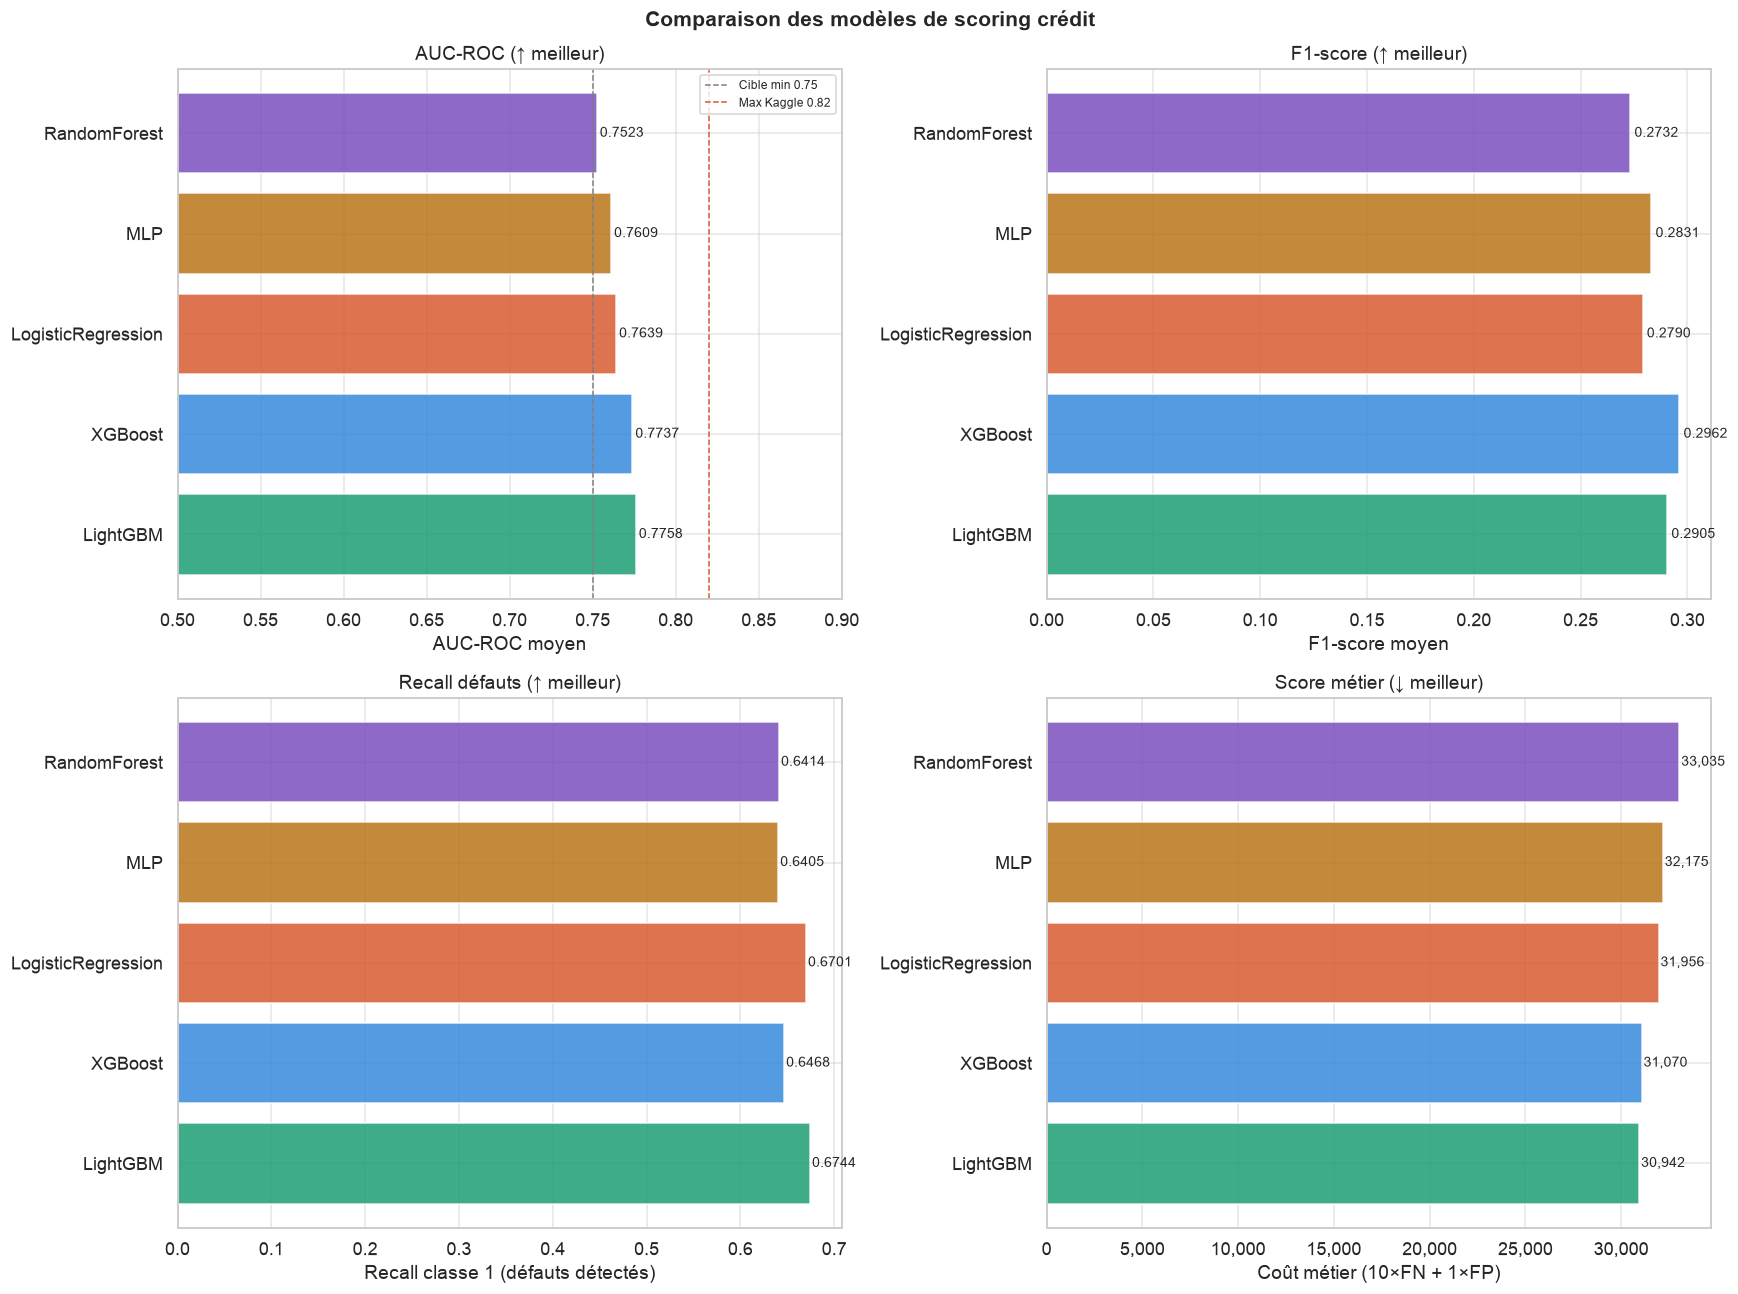

✅ Figure sauvegardée : ./output/figures/comparaison_modeles.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparaison des modèles de scoring crédit", fontsize=14, fontweight="bold")

noms = df_res.index.tolist()
cols = COLORS[:len(noms)]

# ── AUC ──────────────────────────────────────────────────────────
axes[0,0].barh(noms, df_res["AUC"], color=cols, alpha=0.85)
axes[0,0].axvline(0.75, color="gray", ls="--", lw=1, label="Cible min 0.75")
axes[0,0].axvline(0.82, color="#D85A30", ls="--", lw=1, label="Max Kaggle 0.82")
axes[0,0].set_xlabel("AUC-ROC moyen")
axes[0,0].set_title("AUC-ROC (↑ meilleur)")
axes[0,0].legend(fontsize=8)
axes[0,0].set_xlim(0.5, 0.9)
for i, v in enumerate(df_res["AUC"]):
    axes[0,0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# ── F1 ───────────────────────────────────────────────────────────
axes[0,1].barh(noms, df_res["F1"], color=cols, alpha=0.85)
axes[0,1].set_xlabel("F1-score moyen")
axes[0,1].set_title("F1-score (↑ meilleur)")
for i, v in enumerate(df_res["F1"]):
    axes[0,1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# ── Recall classe 1 ───────────────────────────────────────────────
axes[1,0].barh(noms, df_res["Recall_1"], color=cols, alpha=0.85)
axes[1,0].set_xlabel("Recall classe 1 (défauts détectés)")
axes[1,0].set_title("Recall défauts (↑ meilleur)")
for i, v in enumerate(df_res["Recall_1"]):
    axes[1,0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# ── Coût métier ───────────────────────────────────────────────────
axes[1,1].barh(noms, df_res["Cout"], color=cols, alpha=0.85)
axes[1,1].set_xlabel("Coût métier (10×FN + 1×FP)")
axes[1,1].set_title("Score métier (↓ meilleur)")
axes[1,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for i, v in enumerate(df_res["Cout"]):
    axes[1,1].text(v + 100, i, f"{v:,.0f}", va="center", fontsize=9)

plt.tight_layout()
path = os.path.join(FIGURES_DIR, "comparaison_modeles.png")
plt.savefig(path)
plt.show()
mlflow.log_artifact(path, "figures")
print(f"✅ Figure sauvegardée : {path}")


---
## 🏆 6. Sélection du meilleur modèle & Courbes ROC

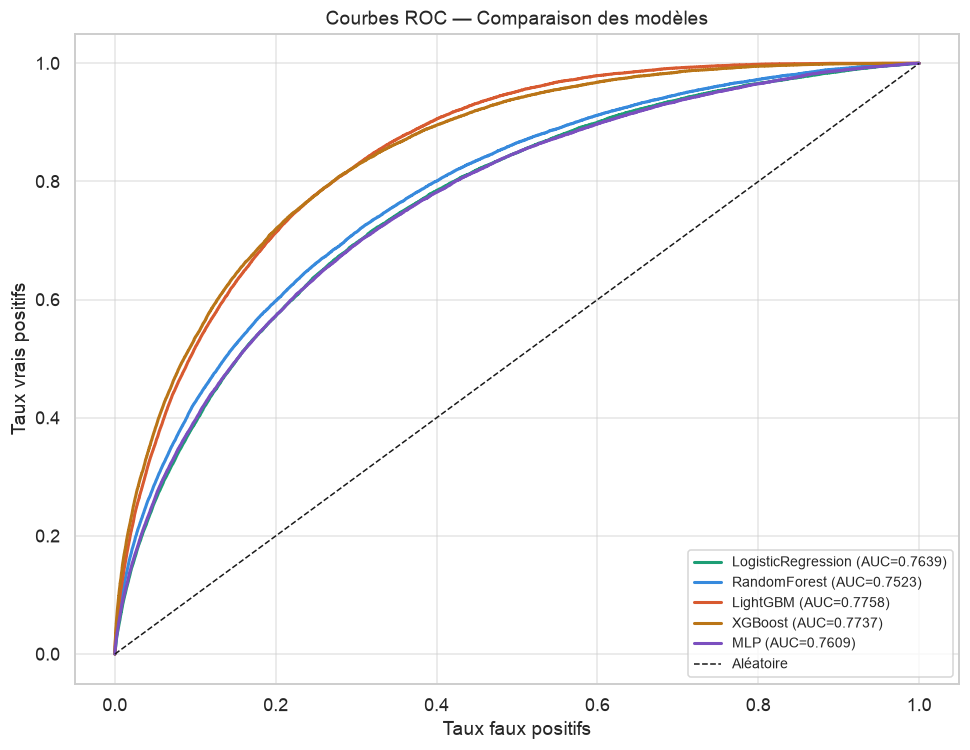

✅ Courbes ROC sauvegardées


In [8]:
# ── Courbes ROC superposées ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for (nom, modele), couleur in zip(MODELES.items(), COLORS):
    X_mod = X_lr if nom in ["LogisticRegression", "MLP"] else X
    # Entraînement final sur tout le train
    if nom == "LightGBM":
        modele.fit(X_mod, y,
                   callbacks=[log_evaluation(-1)])
    else:
        modele.fit(X_mod, y)
    y_proba = modele.predict_proba(X_mod)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc = resultats[nom]["AUC"]
    ax.plot(fpr, tpr, color=couleur, lw=2, label=f"{nom} (AUC={auc:.4f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Aléatoire")
ax.set_xlabel("Taux faux positifs")
ax.set_ylabel("Taux vrais positifs")
ax.set_title("Courbes ROC — Comparaison des modèles")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
path_roc = os.path.join(FIGURES_DIR, "roc_comparaison.png")
plt.savefig(path_roc)
plt.show()
print(f"✅ Courbes ROC sauvegardées")


In [9]:
# ── Sélection & résumé final ──────────────────────────────────────
meilleur_auc  = df_res["AUC"].idxmax()
meilleur_cout = df_res["Cout"].idxmin()

print("╔══════════════════════════════════════════════════════════╗")
print("║         RAPPORT — Comparaison des modèles               ║")
print("╠══════════════════════════════════════════════════════════╣")
for nom in df_res.index:
    r = df_res.loc[nom]
    flag = " 🏆" if nom == meilleur_auc else ""
    print(f"║  {nom:<20} AUC:{r['AUC']:.4f} Coût:{r['Cout']:>8,.0f}{flag:<3}  ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Meilleur AUC    : {meilleur_auc:<36}║")
print(f"║  Meilleur Coût   : {meilleur_cout:<36}║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  Prochaine étape : Interprétabilité SHAP                ║")
print("╚══════════════════════════════════════════════════════════╝")

# Sauvegarde résultats
df_res.to_csv(os.path.join(OUTPUT_DIR, "comparaison_modeles.csv"))
print("\n✅ Résultats sauvegardés : output/comparaison_modeles.csv")


╔══════════════════════════════════════════════════════════╗
║         RAPPORT — Comparaison des modèles               ║
╠══════════════════════════════════════════════════════════╣
║  LightGBM             AUC:0.7758 Coût:  30,942 🏆   ║
║  XGBoost              AUC:0.7737 Coût:  31,070     ║
║  LogisticRegression   AUC:0.7639 Coût:  31,956     ║
║  MLP                  AUC:0.7609 Coût:  32,175     ║
║  RandomForest         AUC:0.7523 Coût:  33,035     ║
╠══════════════════════════════════════════════════════════╣
║  Meilleur AUC    : LightGBM                            ║
║  Meilleur Coût   : LightGBM                            ║
╠══════════════════════════════════════════════════════════╣
║  Prochaine étape : Interprétabilité SHAP                ║
╚══════════════════════════════════════════════════════════╝

✅ Résultats sauvegardés : output/comparaison_modeles.csv


---
## ✅ Étape 3 terminée

**Ce qui a été réalisé :**
- 5 modèles entraînés avec StratifiedKFold 5 folds
- Métriques adaptées : AUC-ROC, F1, Recall défauts, Coût métier
- Déséquilibre géré : `class_weight=balanced` ou `scale_pos_weight`
- Tous les runs trackés dans MLflow
- Visualisations comparatives générées

**Prochaine étape :** Interprétabilité avec SHAP (feature importance globale et locale)
